# Estonian Grid Resilience Simulator

**Research question:** Could Estonia survive a full grid isolation event, and how much does expanding wind capacity reduce the risk?

**This notebook is the final analysis layer.** It combines:
- **Supply side**: ST-GNN quantile forecasts (P10/P50/P90) for 4 scenarios from `Supply_wind.py`
- **Demand side**: SARIMAX Monte Carlo ensemble (1 000 simulations, P5/P50/P95) from `Timeseries.ipynb`

**Prerequisites — run first:**
1. `Supply_wind.py` → generates `data/gnn_supply_scenarios_jan2026.csv`
2. `Timeseries.ipynb` (all cells including the export cell) → generates `data/demand_mc_jan2026.csv`

---

| Scenario | Description |
| --- | --- |
| S1 | Full grid — historical cross-border flows (baseline) |
| S2 | Full isolation — EstLink + Latvia cable severed, no imports |
| S3 | Isolated + 323 MW new wind (Lääneranna, Pärnu, Aidu — enacted plans) |
| S4 | Isolated + 887 MW new wind (S3 + pipeline farms — full buildout) |

**Energy balance:** `balance = domestic_production − consumption`  
Balance < 0 → deficit (blackout risk). Under isolation, all imports = 0.

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")
np.random.seed(42)

SUPPLY_CSV = "../data/gnn_supply_scenarios_jan2026.csv"
DEMAND_CSV = "../data/demand_mc_jan2026.csv"
os.makedirs("../figures", exist_ok=True)

# --- Load supply scenarios ---
assert os.path.exists(SUPPLY_CSV), (
    f"Missing: {SUPPLY_CSV}\n"
    "Run Supply_wind.py first to generate GNN scenario outputs."
)
supply = pd.read_csv(SUPPLY_CSV, parse_dates=["timestamp"])
supply["timestamp"] = pd.to_datetime(supply["timestamp"], utc=True)
supply = supply.set_index("timestamp")
print(f"Supply scenarios: {supply.shape}  ({supply.index.min()} → {supply.index.max()})")

# --- Load demand MC ---
assert os.path.exists(DEMAND_CSV), (
    f"Missing: {DEMAND_CSV}\n"
    "Run Timeseries.ipynb (all cells) first to generate demand MC outputs."
)
demand = pd.read_csv(DEMAND_CSV, parse_dates=["timestamp"])
# Timeseries timestamps are timezone-naive — make UTC for alignment
if demand["timestamp"].dt.tz is None:
    demand["timestamp"] = demand["timestamp"].dt.tz_localize("UTC")
demand = demand.set_index("timestamp")
print(f"Demand quantiles: {demand.shape}  ({demand.index.min()} → {demand.index.max()})")

# Align on common index
idx = supply.index.intersection(demand.index)
supply = supply.loc[idx]
demand = demand.loc[idx]
n_hours = len(idx)
print(f"\nAligned on {n_hours} hours ({idx.min().date()} → {idx.max().date()})")

Supply scenarios: (721, 12)  (2026-01-01 23:00:00+00:00 → 2026-01-31 23:00:00+00:00)
Demand quantiles: (744, 5)  (2026-01-01 00:00:00+00:00 → 2026-01-31 23:00:00+00:00)

Aligned on 721 hours (2026-01-01 → 2026-01-31)


## 1. What actually happened in January 2026

Ground-truth reference: actual production vs actual consumption and the imports that bridged the gap.

In [3]:
actual_prod    = supply["supply_s1_p50"]   # GNN P50 under full grid ≈ production in real grid
actual_demand  = demand["demand_actual"]   # SARIMAX actual consumption Jan 2026
actual_balance = actual_prod - actual_demand

print("=" * 50)
print("  Actual January 2026 (EstLink 2 severed Jan 1)")
print("=" * 50)
print(f"  Mean domestic production (GNN S1 P50): {actual_prod.mean():.0f} MW")
print(f"  Mean consumption (actual):              {actual_demand.mean():.0f} MW")
print(f"  Average production shortfall:           {actual_balance.mean():.0f} MW")
print(f"  (shortfall was covered by imports via LV and the remaining EstLink 1)")
print()
print(f"  Production range: {actual_prod.min():.0f} – {actual_prod.max():.0f} MW")
print(f"  Demand range:     {actual_demand.min():.0f} – {actual_demand.max():.0f} MW")

  Actual January 2026 (EstLink 2 severed Jan 1)
  Mean domestic production (GNN S1 P50): 737 MW
  Mean consumption (actual):              1291 MW
  Average production shortfall:           -555 MW
  (shortfall was covered by imports via LV and the remaining EstLink 1)

  Production range: 366 – 1058 MW
  Demand range:     949 – 1596 MW


## 2. Scenario energy balance: typical (P50) vs stress-test

Two views of each scenario:
- **Typical**: GNN P50 supply − SARIMAX P50 demand (median supply, median demand)
- **Stress test**: GNN P10 supply − SARIMAX P95 demand (worst-case supply meets worst-case demand)

In [4]:
scenarios = [
    ("S1", "Full grid (baseline)",         "supply_s1_p10", "supply_s1_p50", "supply_s1_p90"),
    ("S2", "Full isolation",                "supply_s2_p10", "supply_s2_p50", "supply_s2_p90"),
    ("S3", "Isolated + 323 MW (enacted)",   "supply_s3_p10", "supply_s3_p50", "supply_s3_p90"),
    ("S4", "Isolated + 887 MW (pipeline)",  "supply_s4_p10", "supply_s4_p50", "supply_s4_p90"),
]

results = []
for code, label, col_p10, col_p50, col_p90 in scenarios:
    s_p10 = supply[col_p10].values
    s_p50 = supply[col_p50].values
    s_p90 = supply[col_p90].values
    d_p50 = demand["demand_p50"].values
    d_p95 = demand["demand_p95"].values

    # Typical: P50 supply vs P50 demand
    bal_typ  = s_p50 - d_p50
    def_typ  = (bal_typ < 0).sum()
    mwh_typ  = -bal_typ[bal_typ < 0].sum()   # total energy shortfall (MWh, 1 h intervals)
    worst_typ = bal_typ.min()

    # Stress test: P10 supply vs P95 demand
    bal_str  = s_p10 - d_p95
    def_str  = (bal_str < 0).sum()
    mwh_str  = -bal_str[bal_str < 0].sum()
    worst_str = bal_str.min()

    results.append({
        "Scenario": f"{code}: {label}",
        "Deficit hours (typical)": def_typ,
        "Shortfall MWh (typical)": f"{mwh_typ:,.0f}",
        "Worst hour (typical) MW": f"{worst_typ:+.0f}",
        "Deficit hours (stress)": def_str,
        "Shortfall MWh (stress)": f"{mwh_str:,.0f}",
        "Worst hour (stress) MW": f"{worst_str:+.0f}",
    })

    print(f"\n  {code}: {label}")
    print(f"    [Typical]  Deficit hours: {def_typ:3d}/744  |  Shortfall: {mwh_typ:7,.0f} MWh  |  Worst hour: {worst_typ:+.0f} MW")
    print(f"    [Stress ]  Deficit hours: {def_str:3d}/744  |  Shortfall: {mwh_str:7,.0f} MWh  |  Worst hour: {worst_str:+.0f} MW")

results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))


  S1: Full grid (baseline)
    [Typical]  Deficit hours: 721/744  |  Shortfall: 343,731 MWh  |  Worst hour: -975 MW
    [Stress ]  Deficit hours: 721/744  |  Shortfall: 619,265 MWh  |  Worst hour: -1309 MW

  S2: Full isolation
    [Typical]  Deficit hours: 721/744  |  Shortfall: 341,797 MWh  |  Worst hour: -975 MW
    [Stress ]  Deficit hours: 721/744  |  Shortfall: 617,552 MWh  |  Worst hour: -1308 MW

  S3: Isolated + 323 MW (enacted)
    [Typical]  Deficit hours: 718/744  |  Shortfall: 323,006 MWh  |  Worst hour: -946 MW
    [Stress ]  Deficit hours: 721/744  |  Shortfall: 602,872 MWh  |  Worst hour: -1296 MW

  S4: Isolated + 887 MW (pipeline)
    [Typical]  Deficit hours: 708/744  |  Shortfall: 297,735 MWh  |  Worst hour: -897 MW
    [Stress ]  Deficit hours: 721/744  |  Shortfall: 583,179 MWh  |  Worst hour: -1290 MW

                         Scenario  Deficit hours (typical) Shortfall MWh (typical) Worst hour (typical) MW  Deficit hours (stress) Shortfall MWh (stress) Worst ho

## 3. Time-series: supply vs demand under isolation

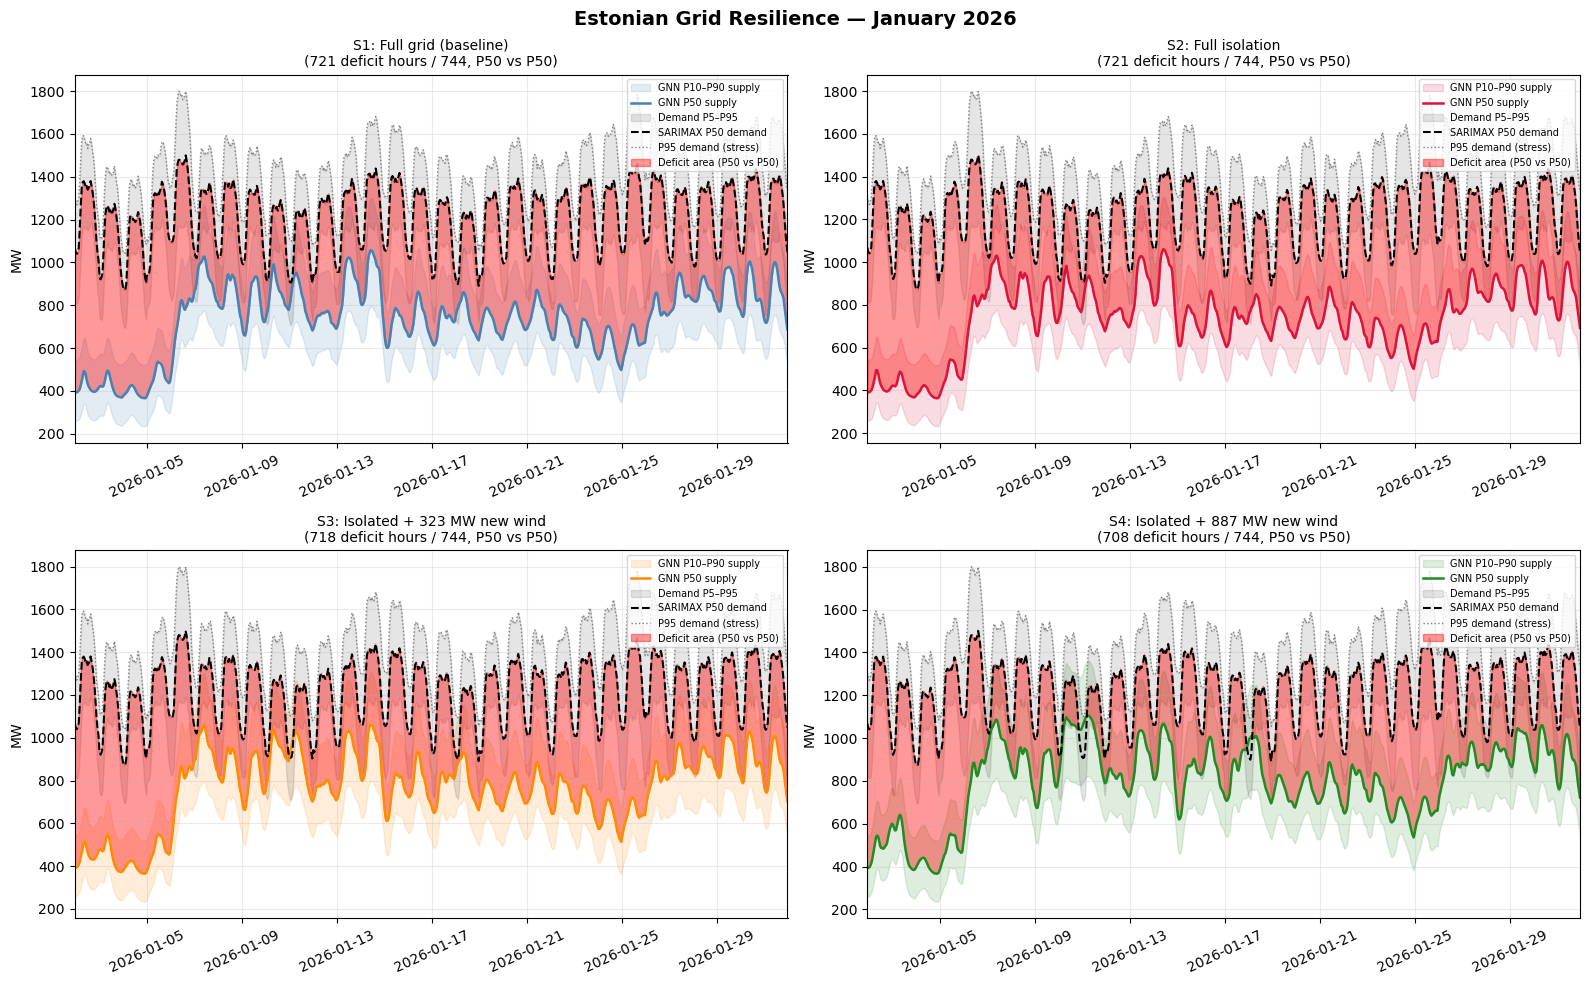

Saved: figures/resilience_supply_demand.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Estonian Grid Resilience — January 2026", fontsize=14, fontweight="bold")

scenario_plot_data = [
    (axes[0, 0], "S1", "Full grid (baseline)",        "supply_s1_p10", "supply_s1_p50", "supply_s1_p90", "steelblue"),
    (axes[0, 1], "S2", "Full isolation",               "supply_s2_p10", "supply_s2_p50", "supply_s2_p90", "crimson"),
    (axes[1, 0], "S3", "Isolated + 323 MW new wind",   "supply_s3_p10", "supply_s3_p50", "supply_s3_p90", "darkorange"),
    (axes[1, 1], "S4", "Isolated + 887 MW new wind",   "supply_s4_p10", "supply_s4_p50", "supply_s4_p90", "forestgreen"),
]

ts = idx  # DatetimeIndex

for ax, code, title, c_p10, c_p50, c_p90, col in scenario_plot_data:
    s_p10 = supply[c_p10].values
    s_p50 = supply[c_p50].values
    s_p90 = supply[c_p90].values
    d_p50 = demand["demand_p50"].values
    d_p95 = demand["demand_p95"].values

    # Supply bands
    ax.fill_between(ts, s_p10, s_p90, alpha=0.15, color=col, label="GNN P10–P90 supply")
    ax.plot(ts, s_p50, lw=1.8, color=col, label="GNN P50 supply")

    # Demand bands
    ax.fill_between(ts, demand["demand_p5"].values, d_p95, alpha=0.1, color="black", label="Demand P5–P95")
    ax.plot(ts, d_p50, lw=1.5, color="black", ls="--", label="SARIMAX P50 demand")
    ax.plot(ts, d_p95, lw=1.0, color="grey",  ls=":",  label="P95 demand (stress)")

    # Shade deficit hours (P50 supply < P50 demand)
    deficit_mask = s_p50 < d_p50
    ax.fill_between(ts, s_p50, d_p50, where=deficit_mask,
                    alpha=0.4, color="red", label="Deficit area (P50 vs P50)")

    bal_typ = s_p50 - d_p50
    def_h   = (bal_typ < 0).sum()

    ax.set_title(f"{code}: {title}\n({def_h} deficit hours / 744, P50 vs P50)", fontsize=10)
    ax.set_ylabel("MW")
    ax.set_xlim(ts.min(), ts.max())
    ax.tick_params(axis="x", rotation=25)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.savefig("../figures/resilience_supply_demand.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: figures/resilience_supply_demand.png")

## 4. Deficit hour distribution across scenarios

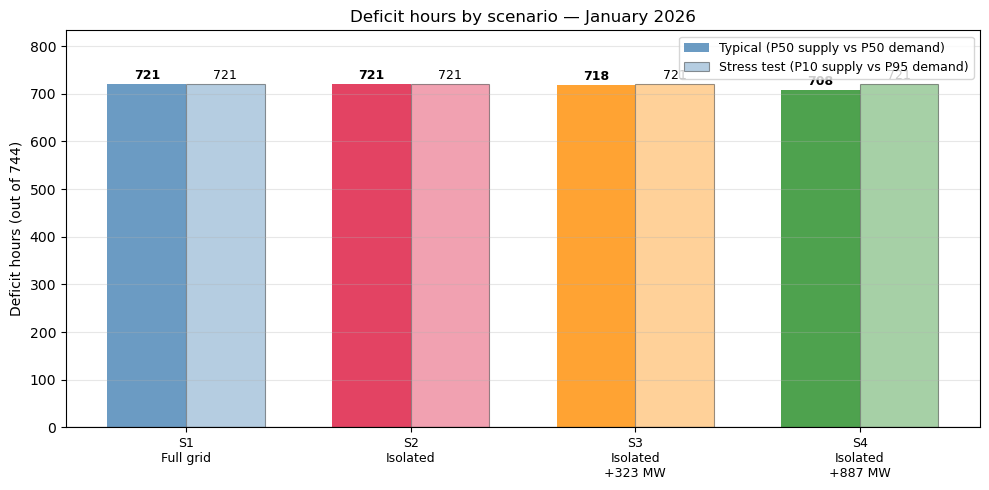

Saved: figures/resilience_deficit_hours.png


In [6]:
labels  = ["S1\nFull grid", "S2\nIsolated", "S3\nIsolated\n+323 MW", "S4\nIsolated\n+887 MW"]
colors  = ["steelblue", "crimson", "darkorange", "forestgreen"]
cols_p50 = ["supply_s1_p50", "supply_s2_p50", "supply_s3_p50", "supply_s4_p50"]
cols_p10 = ["supply_s1_p10", "supply_s2_p10", "supply_s3_p10", "supply_s4_p10"]

d_p50_arr = demand["demand_p50"].values
d_p95_arr = demand["demand_p95"].values

def_typ  = [(supply[c].values - d_p50_arr < 0).sum() for c in cols_p50]
def_str  = [(supply[c].values - d_p95_arr < 0).sum() for c in cols_p10]

x = np.arange(4)
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, def_typ, w, color=colors, alpha=0.80, label="Typical (P50 supply vs P50 demand)")
bars2 = ax.bar(x + w/2, def_str, w, color=colors, alpha=0.40, edgecolor="black", lw=0.8,
               label="Stress test (P10 supply vs P95 demand)")

for bar, v in zip(bars1, def_typ):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4, str(v),
            ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, v in zip(bars2, def_str):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4, str(v),
            ha="center", va="bottom", fontsize=9)

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Deficit hours (out of 744)")
ax.set_title("Deficit hours by scenario — January 2026", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")
ax.set_ylim(0, 744 * 1.12)

plt.tight_layout()
plt.savefig("../figures/resilience_deficit_hours.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: figures/resilience_deficit_hours.png")

## 5. Break-even analysis: how much wind capacity to close the gap?

We have three reference points (S2, S3, S4) under isolation. Linear interpolation between them estimates what total new wind capacity would reduce deficit hours to zero.

**Assumption:** the marginal reduction in deficit hours per additional MW of wind is approximately constant across the range 0–887 MW of new capacity. This is reasonable for moderate additions where the wind profile is similar.

In [7]:
d_p50 = demand["demand_p50"].values
d_p95 = demand["demand_p95"].values

# Reference points from S2, S3, S4 (isolation scenarios)
s2_p50 = supply["supply_s2_p50"].values
s3_p50 = supply["supply_s3_p50"].values
s4_p50 = supply["supply_s4_p50"].values
s2_p10 = supply["supply_s2_p10"].values
s3_p10 = supply["supply_s3_p10"].values
s4_p10 = supply["supply_s4_p10"].values

wind_mw_points = [0, 323, 887]   # new capacity added in S2, S3, S4

def deficit_hours(supply_arr, demand_arr):
    return int((supply_arr - demand_arr < 0).sum())

# Typical scenario deficit hours
dh_typ = [
    deficit_hours(s2_p50, d_p50),
    deficit_hours(s3_p50, d_p50),
    deficit_hours(s4_p50, d_p50),
]
# Stress test deficit hours
dh_str = [
    deficit_hours(s2_p10, d_p95),
    deficit_hours(s3_p10, d_p95),
    deficit_hours(s4_p10, d_p95),
]

print("Break-even reference points (isolation scenarios only):")
print(f"  S2 (  0 MW new): {dh_typ[0]:3d} deficit hours (typical)  |  {dh_str[0]:3d} (stress)")
print(f"  S3 (+323 MW):    {dh_typ[1]:3d} deficit hours (typical)  |  {dh_str[1]:3d} (stress)")
print(f"  S4 (+887 MW):    {dh_typ[2]:3d} deficit hours (typical)  |  {dh_str[2]:3d} (stress)")

# Linear fit: deficit hours = a + b * new_MW
# Fit through S2–S4 reference points (3 points, 1 free parameter with intercept)
fit_typ = np.polyfit(wind_mw_points, dh_typ, deg=1)
fit_str = np.polyfit(wind_mw_points, dh_str, deg=1)

def breakeven_mw(fit):
    # solve fit[0]*x + fit[1] = 0
    if fit[0] >= 0:
        return None  # doesn't converge (would need negative wind)
    return -fit[1] / fit[0]

be_typ = breakeven_mw(fit_typ)
be_str = breakeven_mw(fit_str)

print(f"\nLinear break-even extrapolation:")
if be_typ is not None:
    print(f"  Typical scenario:  {be_typ:,.0f} MW new wind → 0 deficit hours")
else:
    print("  Typical scenario:  deficit hours not decreasing — check GNN outputs")
if be_str is not None:
    print(f"  Stress test:       {be_str:,.0f} MW new wind → 0 deficit hours (P10 supply vs P95 demand)")
else:
    print("  Stress test:       deficit hours not decreasing — check GNN outputs")

Break-even reference points (isolation scenarios only):
  S2 (  0 MW new): 721 deficit hours (typical)  |  721 (stress)
  S3 (+323 MW):    718 deficit hours (typical)  |  721 (stress)
  S4 (+887 MW):    708 deficit hours (typical)  |  721 (stress)

Linear break-even extrapolation:
  Typical scenario:  48,109 MW new wind → 0 deficit hours
  Stress test:       deficit hours not decreasing — check GNN outputs


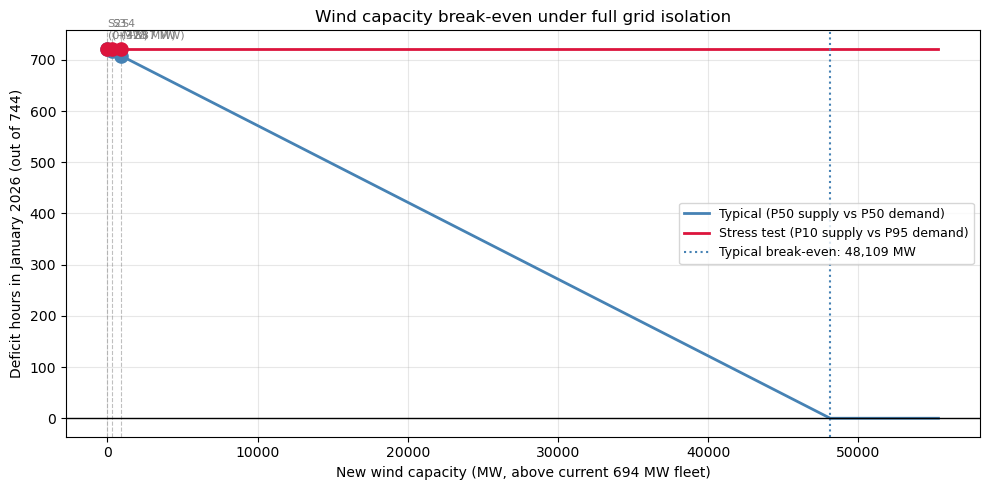

Saved: figures/resilience_breakeven.png


In [8]:
mw_range = np.linspace(0, max(be_typ or 2000, be_str or 2000) * 1.15, 400)
trend_typ = np.polyval(fit_typ, mw_range).clip(0)
trend_str = np.polyval(fit_str, mw_range).clip(0)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(mw_range, trend_typ, lw=2, color="steelblue", label="Typical (P50 supply vs P50 demand)")
ax.plot(mw_range, trend_str, lw=2, color="crimson",   label="Stress test (P10 supply vs P95 demand)")

# Mark reference points
ax.scatter(wind_mw_points, dh_typ, s=90, zorder=5, color="steelblue")
ax.scatter(wind_mw_points, dh_str, s=90, zorder=5, color="crimson")

# Label reference scenarios
for mw, label in zip(wind_mw_points, ["S2\n(0 MW)", "S3\n(+323 MW)", "S4\n(+887 MW)"]):
    ax.axvline(mw, color="grey", lw=0.8, ls="--", alpha=0.5)
    ax.text(mw + 10, max(dh_str) * 1.03, label, fontsize=8, color="grey")

# Break-even markers
if be_typ is not None and 0 < be_typ < mw_range[-1]:
    ax.axvline(be_typ, color="steelblue", lw=1.5, ls=":",
               label=f"Typical break-even: {be_typ:,.0f} MW")
if be_str is not None and 0 < be_str < mw_range[-1]:
    ax.axvline(be_str, color="crimson", lw=1.5, ls=":",
               label=f"Stress break-even: {be_str:,.0f} MW")

ax.axhline(0, color="black", lw=1)
ax.set_xlabel("New wind capacity (MW, above current 694 MW fleet)")
ax.set_ylabel("Deficit hours in January 2026 (out of 744)")
ax.set_title("Wind capacity break-even under full grid isolation", fontsize=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/resilience_breakeven.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: figures/resilience_breakeven.png")

## 6. Hourly balance profile — what does an isolation event look like?

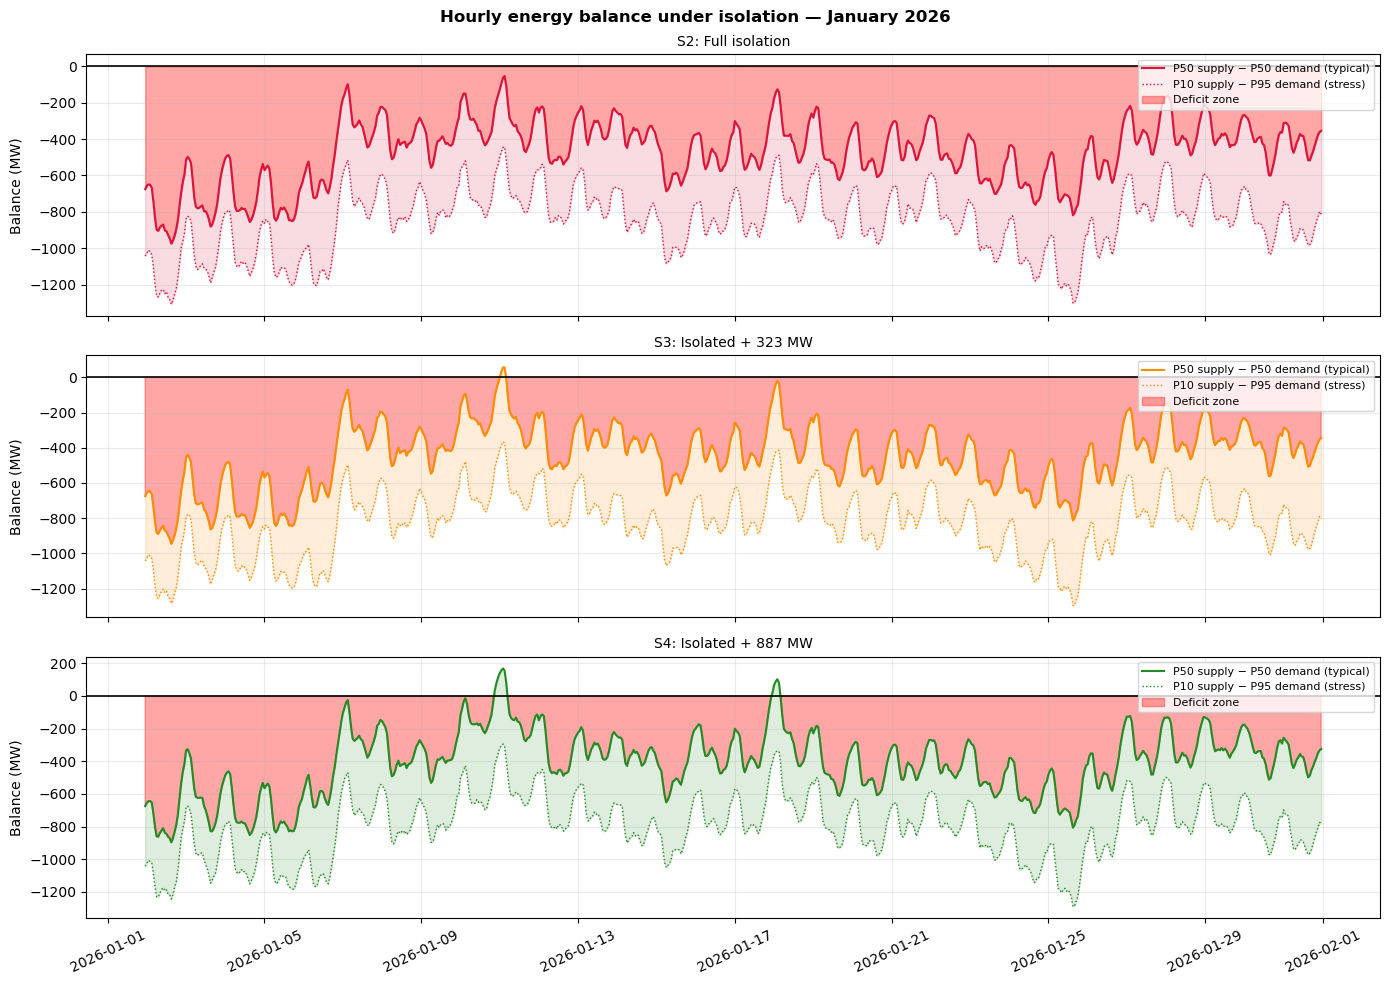

Saved: figures/resilience_hourly_balance.png


In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("Hourly energy balance under isolation — January 2026", fontsize=12, fontweight="bold")

plot_configs = [
    (axes[0], "S2: Full isolation",         s2_p10, s2_p50, supply["supply_s2_p90"].values, "crimson"),
    (axes[1], "S3: Isolated + 323 MW",      s3_p10, s3_p50, supply["supply_s3_p90"].values, "darkorange"),
    (axes[2], "S4: Isolated + 887 MW",      s4_p10, s4_p50, supply["supply_s4_p90"].values, "forestgreen"),
]

for ax, title, p10, p50, p90, col in plot_configs:
    balance_typ = p50 - d_p50
    balance_low = p10 - d_p95   # stress

    ax.fill_between(ts, balance_low, balance_typ, alpha=0.15, color=col)
    ax.plot(ts, balance_typ, lw=1.5, color=col, label="P50 supply − P50 demand (typical)")
    ax.plot(ts, balance_low, lw=1.0, color=col, ls=":", label="P10 supply − P95 demand (stress)")

    # Shade deficit
    ax.fill_between(ts, balance_typ, 0, where=(balance_typ < 0),
                    alpha=0.35, color="red", label="Deficit zone")

    ax.axhline(0, color="black", lw=1.2)
    ax.set_ylabel("Balance (MW)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.25)

axes[-1].tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig("../figures/resilience_hourly_balance.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved: figures/resilience_hourly_balance.png")

## 7. Policy summary

In [10]:
d_p50 = demand["demand_p50"].values
d_p95 = demand["demand_p95"].values

rows = []
for code, label, c_p10, c_p50, c_p90 in scenarios:
    s10 = supply[c_p10].values
    s50 = supply[c_p50].values

    bal_typ = s50 - d_p50
    bal_str = s10 - d_p95

    dh_typ = (bal_typ < 0).sum()
    dh_str = (bal_str < 0).sum()
    mwh_typ = -bal_typ[bal_typ < 0].sum()
    mwh_str = -bal_str[bal_str < 0].sum()

    rows.append({
        "Scenario": f"{code}: {label}",
        "Mean supply P50 (MW)": f"{s50.mean():.0f}",
        "Deficit hrs (typical)": dh_typ,
        "Shortfall GWh (typical)": f"{mwh_typ/1000:.1f}",
        "Deficit hrs (stress test)": dh_str,
        "Shortfall GWh (stress)": f"{mwh_str/1000:.1f}",
    })

summary_df = pd.DataFrame(rows)
print("="*80)
print("  RESILIENCE SUMMARY — January 2026 (744 hours)")
print("  Typical   = P50 GNN supply vs P50 SARIMAX demand")
print("  Stress    = P10 GNN supply vs P95 SARIMAX demand")
print("="*80)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("  BREAK-EVEN (linear extrapolation from S2 / S3 / S4):")
if be_typ is not None:
    print(f"  Typical:    {be_typ:,.0f} MW of new wind capacity above current 694 MW")
if be_str is not None:
    print(f"  Stress test:{be_str:,.0f} MW of new wind capacity above current 694 MW")
print("\n  Note: break-even assumes wind production profile similar to ERA5 January 2026")
print("  (capacity factor ~15%  — a low-wind month, consistent with crisis conditions)")
print("="*80)

  RESILIENCE SUMMARY — January 2026 (744 hours)
  Typical   = P50 GNN supply vs P50 SARIMAX demand
  Stress    = P10 GNN supply vs P95 SARIMAX demand
                        Scenario Mean supply P50 (MW)  Deficit hrs (typical) Shortfall GWh (typical)  Deficit hrs (stress test) Shortfall GWh (stress)
        S1: Full grid (baseline)                  737                    721                   343.7                        721                  619.3
              S2: Full isolation                  740                    721                   341.8                        721                  617.6
 S3: Isolated + 323 MW (enacted)                  766                    718                   323.0                        721                  602.9
S4: Isolated + 887 MW (pipeline)                  803                    708                   297.7                        721                  583.2

  BREAK-EVEN (linear extrapolation from S2 / S3 / S4):
  Typical:    48,109 MW of new wind cap